# Abundant regularization sweep — final Gini-refinement analyzer

This notebook analyzes the completed coarse sweep for graph regularization in
the abundant-data regime.

It performs **analysis only**:

- no environment rollouts,
- no graph-identifier training,
- no cache reconstruction.

It expects results from:

`experiment_2026_09_25_abundant_regularization_sweep`

and compares:

- **none** — finalized September model;
- **theta_l2** — paper-inspired \(L_2(\Theta)\);
- **entropy** — normalized row-entropy penalty;
- **gini** — normalized row-Gini impurity penalty.

The main tuning objective is not merely "make \(A\) sparse". We inspect jointly:

1. weighted-\(A\) recovery;
2. support/ranking recovery;
3. graph concentration;
4. one-step prediction;
5. downstream control.

A useful regularizer should improve graph recovery without materially degrading
control.

### Theta-L2 refinement

This version expects the refined paper-style grid $10^{-8},10^{-7},10^{-6},10^{-5},10^{-4}$, while retaining the existing entropy and Gini conditions.

### Gini refinement grid

The final Gini grid is $\{10^{-6},10^{-5},3\times10^{-5},5\times10^{-5},10^{-4},2\times10^{-4},3\times10^{-4},5\times10^{-4},10^{-3}\}$.


In [25]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t as student_t

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 320)
pd.set_option("display.max_rows", 300)

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing opinion_dynamics/.")

REPO_ROOT = find_repo_root()
RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / "experiment_2026_09_25_abundant_regularization_sweep"
)

ALL_RUNS = RESULTS_DIR / "regularization_sweep_all_runs.csv"
COMPLETION = RESULTS_DIR / "COMPUTATION_COMPLETE.json"

for path in [ALL_RUNS, COMPLETION]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Repository:", REPO_ROOT)
print("Results:", RESULTS_DIR)


Repository: d:\Work\repos\RL\unknown_graph_networks
Results: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_09_25_abundant_regularization_sweep


## Completion and coverage audit

In [26]:
completion = json.loads(COMPLETION.read_text(encoding="utf-8"))
display(pd.Series(completion, name="value").to_frame())

assert completion["status"] == "success"
assert completion["study_name"] == "abundant_regularization_sweep_unbounded_lambda1"
assert int(completion["n_environments"]) == 195
assert int(completion["learning_seed"]) == 0
assert int(completion["n_regularized_variants"]) == 18
assert int(completion["n_new_fits"]) == 975
assert int(completion["n_reused_fits"]) == 2535

df = pd.read_csv(ALL_RUNS)

required = {
    "environment_id", "scenario_class", "family", "dynamics",
    "regularizer_kind", "regularizer_lambda",
    "mean_end", "mean_over_trajectory",
    "model_over_identity",
    "A_MAE", "A_Fro", "row_TV",
    "true_edge_mass", "support_topdegree_recall", "edge_AP",
    "centrality_L1", "row_entropy_norm", "effective_neighbors",
}
missing_cols = sorted(required - set(df.columns))
if missing_cols:
    raise RuntimeError(f"Missing required columns: {missing_cols}")

df["regularizer_lambda"] = df["regularizer_lambda"].astype(float)

conditions = (
    df[["regularizer_kind", "regularizer_lambda"]]
    .drop_duplicates()
    .sort_values(["regularizer_kind", "regularizer_lambda"])
    .reset_index(drop=True)
)

coverage = (
    df.groupby(["regularizer_kind", "regularizer_lambda"])
    .agg(rows=("environment_id", "size"),
         environments=("environment_id", "nunique"))
    .reset_index()
    .sort_values(["regularizer_kind", "regularizer_lambda"])
)

print("Conditions:", len(conditions))
print("Rows:", len(df))
display(coverage)

assert len(conditions) == 19
assert len(df) == 195 * 19
assert (coverage["rows"] == 195).all()
assert (coverage["environments"] == 195).all()

print("\nCOVERAGE AUDIT PASSED: 19 conditions × 195 paired environments.")


,value
status,success
study_name,abundant_regularization_sweep_unbounded_lambda1
pipeline_version,2026-09-27-regularization-gini-refinement-v3
git_commit,34fe426
config_hash,a12c7a5468134984
implementation_hash,af02e1943e3b02374bf80e6ababe8ec607aa3ffd828f74...
source_study,abundant_all_dynamics_multitopology_multiseed_...
source_config_hash,2dfd8a85437a16ee
n_environments,195
learning_seed,0


Conditions: 19
Rows: 3705


,regularizer_kind,regularizer_lambda,rows,environments
0,entropy,1.000000e-06,195,195
1,entropy,1.000000e-05,195,195
2,entropy,1.000000e-04,195,195
3,entropy,1.000000e-03,195,195
4,gini,1.000000e-06,195,195
5,gini,1.000000e-05,195,195
6,gini,3.000000e-05,195,195
7,gini,5.000000e-05,195,195
8,gini,1.000000e-04,195,195
9,gini,2.000000e-04,195,195



COVERAGE AUDIT PASSED: 19 conditions × 195 paired environments.


## Overall sweep summary

Main directions:

- `mean_end`: higher is better;
- `model_over_identity`: lower is better;
- `row_TV`: lower is better;
- `true_edge_mass`: higher is better;
- `edge_AP`: higher is better;
- `centrality_L1`: lower is better;
- `row_entropy_norm`: lower means more concentrated rows;
- `effective_neighbors`: lower means more concentrated rows.


In [27]:
ref = df[
    (df["regularizer_kind"] == "none")
    & (df["regularizer_lambda"] == 0.0)
].set_index("environment_id")
assert len(ref) == 195

metric_cols = [
    "mean_end", "mean_over_trajectory", "model_over_identity",
    "row_TV", "true_edge_mass", "support_topdegree_recall",
    "edge_AP", "centrality_L1", "row_entropy_norm", "effective_neighbors",
]

work = df.copy()
for metric in metric_cols:
    work[f"delta_{metric}_vs_none"] = work.apply(
        lambda r: float(r[metric]) - float(ref.loc[r["environment_id"], metric]),
        axis=1,
    )

summary = (
    work.groupby(["regularizer_kind", "regularizer_lambda"], as_index=False)
    .agg(
        n=("environment_id", "size"),
        mean_end=("mean_end", "mean"),
        mean_over_trajectory=("mean_over_trajectory", "mean"),
        prediction_ratio=("model_over_identity", "mean"),
        row_TV=("row_TV", "mean"),
        true_edge_mass=("true_edge_mass", "mean"),
        support_recall=("support_topdegree_recall", "mean"),
        edge_AP=("edge_AP", "mean"),
        centrality_L1=("centrality_L1", "mean"),
        row_entropy=("row_entropy_norm", "mean"),
        effective_neighbors=("effective_neighbors", "mean"),
        delta_control=("delta_mean_end_vs_none", "mean"),
        delta_prediction_ratio=("delta_model_over_identity_vs_none", "mean"),
        delta_row_TV=("delta_row_TV_vs_none", "mean"),
        delta_true_edge_mass=("delta_true_edge_mass_vs_none", "mean"),
        delta_edge_AP=("delta_edge_AP_vs_none", "mean"),
        delta_centrality_L1=("delta_centrality_L1_vs_none", "mean"),
    )
)

display(summary.sort_values(["regularizer_kind", "regularizer_lambda"]).round(6))


,regularizer_kind,regularizer_lambda,n,mean_end,mean_over_trajectory,prediction_ratio,row_TV,true_edge_mass,support_recall,edge_AP,centrality_L1,row_entropy,effective_neighbors,delta_control,delta_prediction_ratio,delta_row_TV,delta_true_edge_mass,delta_edge_AP,delta_centrality_L1
0,entropy,0.000001,195,0.768662,0.651045,0.638227,0.575823,0.433720,0.732983,0.741728,0.479880,0.903186,9.145097,0.000034,-0.000084,-0.000173,0.000197,-0.000120,-0.000201
1,entropy,0.000010,195,0.768169,0.650791,0.637492,0.574308,0.435473,0.731340,0.740164,0.478098,0.901170,9.054728,-0.000458,-0.000818,-0.001688,0.001950,-0.001683,-0.001984
2,entropy,0.000100,195,0.765836,0.648711,0.633075,0.566109,0.448689,0.705993,0.712357,0.465901,0.874409,7.925858,-0.002792,-0.005236,-0.009887,0.015165,-0.029491,-0.014180
3,entropy,0.001000,195,0.745212,0.636242,0.689548,0.655201,0.381751,0.458812,0.488856,0.536793,0.750924,5.462997,-0.023416,0.051238,0.079204,-0.051773,-0.252991,0.056711
4,gini,0.000001,195,0.768670,0.651027,0.638264,0.575897,0.433634,0.733325,0.741801,0.479972,0.903293,9.149989,0.000042,-0.000047,-0.000099,0.000111,-0.000046,-0.000110
5,gini,0.000010,195,0.768369,0.650867,0.637848,0.575011,0.434631,0.731775,0.741016,0.478988,0.902289,9.105655,-0.000259,-0.000463,-0.000985,0.001108,-0.000832,-0.001094
6,gini,0.000030,195,0.768263,0.650671,0.636948,0.573100,0.436841,0.730219,0.738900,0.476815,0.899942,9.001588,-0.000365,-0.001362,-0.002896,0.003318,-0.002947,-0.003266
7,gini,0.000050,195,0.768238,0.650605,0.636091,0.571283,0.439030,0.729028,0.736688,0.474679,0.897418,8.888880,-0.000390,-0.002219,-0.004713,0.005507,-0.005159,-0.005402
8,gini,0.000100,195,0.767630,0.650117,0.634230,0.567461,0.444259,0.722188,0.728919,0.469769,0.890150,8.562281,-0.000998,-0.004080,-0.008535,0.010735,-0.012928,-0.010313
9,gini,0.000200,195,0.766211,0.649031,0.632539,0.564033,0.452352,0.703756,0.710836,0.464242,0.870866,7.752073,-0.002416,-0.005771,-0.011964,0.018829,-0.031012,-0.015840


## Best observed setting within each regularizer family

In [28]:
regularized = summary[summary["regularizer_kind"] != "none"].copy()
best_rows = []

for kind, g in regularized.groupby("regularizer_kind"):
    best_rows.append({
        "regularizer_kind": kind,
        "lambda_lowest_row_TV": float(g.loc[g["row_TV"].idxmin(), "regularizer_lambda"]),
        "lowest_row_TV": float(g["row_TV"].min()),
        "lambda_highest_true_edge_mass": float(g.loc[g["true_edge_mass"].idxmax(), "regularizer_lambda"]),
        "highest_true_edge_mass": float(g["true_edge_mass"].max()),
        "lambda_highest_edge_AP": float(g.loc[g["edge_AP"].idxmax(), "regularizer_lambda"]),
        "highest_edge_AP": float(g["edge_AP"].max()),
        "lambda_highest_control": float(g.loc[g["mean_end"].idxmax(), "regularizer_lambda"]),
        "highest_control": float(g["mean_end"].max()),
        "lambda_lowest_prediction_ratio": float(g.loc[g["prediction_ratio"].idxmin(), "regularizer_lambda"]),
        "lowest_prediction_ratio": float(g["prediction_ratio"].min()),
    })

best_by_family = pd.DataFrame(best_rows)
display(best_by_family.round(6))

baseline = summary[summary["regularizer_kind"] == "none"].iloc[0]
print("\nNo-regularization reference:")
display(
    baseline[
        ["mean_end", "prediction_ratio", "row_TV", "true_edge_mass",
         "edge_AP", "centrality_L1", "row_entropy", "effective_neighbors"]
    ].to_frame("none")
)


,regularizer_kind,lambda_lowest_row_TV,lowest_row_TV,lambda_highest_true_edge_mass,highest_true_edge_mass,lambda_highest_edge_AP,highest_edge_AP,lambda_highest_control,highest_control,lambda_lowest_prediction_ratio,lowest_prediction_ratio
0,entropy,0.0001,0.566109,0.0001,0.448689,0.000001,0.741728,0.000001,0.768662,0.0001,0.633075
1,gini,0.0002,0.564033,0.0003,0.455923,0.000001,0.741801,0.000001,0.768670,0.0002,0.632539
2,theta_l2,0.0000,0.577947,0.0000,0.431380,0.000000,0.746367,0.000000,0.768651,0.0000,0.639353



No-regularization reference:


,none
mean_end,0.768628
prediction_ratio,0.63831
row_TV,0.575996
true_edge_mass,0.433523
edge_AP,0.741848
centrality_L1,0.480081
row_entropy,0.903403
effective_neighbors,9.154827


## Paired uncertainty versus no regularization

Structured cases use a paired Student-\(t\) interval.

Generic dynamics use the same crossed \(5\times5\) topology/opinion bootstrap
logic as the canonical paper analysis.


In [29]:
def student_t_ci(values: np.ndarray, confidence: float = 0.95):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    mean = float(x.mean())
    if len(x) <= 1:
        return mean, np.nan, np.nan
    crit = float(student_t.ppf(0.5 + confidence / 2, df=len(x) - 1))
    half = crit * float(x.std(ddof=1)) / math.sqrt(len(x))
    return mean, mean - half, mean + half

def crossed_bootstrap_ci(group: pd.DataFrame, col: str, n_boot: int = 20_000, seed: int = 20260926):
    pivot = group.pivot(index="topology_seed", columns="opinion_seed", values=col)
    if pivot.shape != (5, 5) or pivot.isna().any().any():
        raise ValueError(f"Incomplete 5x5 crossed design for {col}: {pivot.shape}")
    matrix = pivot.to_numpy(float)
    rng = np.random.default_rng(seed)
    r = rng.integers(0, 5, size=(n_boot, 5))
    c = rng.integers(0, 5, size=(n_boot, 5))
    sampled = matrix[r[:, :, None], c[:, None, :]]
    boot = sampled.mean(axis=(1, 2))
    lo, hi = np.quantile(boot, [0.025, 0.975])
    return float(matrix.mean()), float(lo), float(hi)

paired_rows = []

for (kind, lam), candidate in work[
    work["regularizer_kind"] != "none"
].groupby(["regularizer_kind", "regularizer_lambda"], sort=False):
    for (scenario, dynamics), g in candidate.groupby(
        ["scenario_class", "dynamics"], sort=False
    ):
        for metric in ["mean_end", "row_TV", "true_edge_mass", "edge_AP", "centrality_L1"]:
            delta_col = f"delta_{metric}_vs_none"
            if (
                scenario == "unstructured_random"
                and len(g) == 25
                and g["topology_seed"].nunique() == 5
                and g["opinion_seed"].nunique() == 5
            ):
                mean, lo, hi = crossed_bootstrap_ci(g, delta_col)
                method = "crossed bootstrap"
            else:
                mean, lo, hi = student_t_ci(g[delta_col].to_numpy())
                method = "paired Student-t"

            paired_rows.append({
                "regularizer_kind": kind,
                "regularizer_lambda": float(lam),
                "scenario_class": scenario,
                "dynamics": dynamics,
                "metric": metric,
                "delta_vs_none_mean": mean,
                "ci_low": lo,
                "ci_high": hi,
                "ci_method": method,
                "n_environments": len(g),
            })

paired_ci = pd.DataFrame(paired_rows)

print("Control delta vs none:")
display(
    paired_ci[paired_ci["metric"] == "mean_end"]
    .sort_values(["scenario_class", "dynamics", "regularizer_kind", "regularizer_lambda"])
    .round(6)
)


Control delta vs none:


,regularizer_kind,regularizer_lambda,scenario_class,dynamics,metric,delta_vs_none_mean,ci_low,ci_high,ci_method,n_environments
260,entropy,0.000001,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
305,entropy,0.000010,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
350,entropy,0.000100,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
395,entropy,0.001000,structured_mechanism,friedkinjohnsen,mean_end,0.000005,-0.000006,0.000016,paired Student-t,15
440,gini,0.000001,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
485,gini,0.000010,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
530,gini,0.000030,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
575,gini,0.000050,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
620,gini,0.000100,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
665,gini,0.000200,structured_mechanism,friedkinjohnsen,mean_end,0.000000,0.000000,0.000000,paired Student-t,15


## Structured HK — primary stress test

In [30]:
hk = (
    work[
        (work["scenario_class"] == "structured_mechanism")
        & (work["dynamics"] == "hegselmannkrause")
    ]
    .groupby(["regularizer_kind", "regularizer_lambda"], as_index=False)
    .agg(
        n=("environment_id", "size"),
        control=("mean_end", "mean"),
        prediction_ratio=("model_over_identity", "mean"),
        row_TV=("row_TV", "mean"),
        true_edge_mass=("true_edge_mass", "mean"),
        support_recall=("support_topdegree_recall", "mean"),
        edge_AP=("edge_AP", "mean"),
        centrality_L1=("centrality_L1", "mean"),
        row_entropy=("row_entropy_norm", "mean"),
        effective_neighbors=("effective_neighbors", "mean"),
        delta_control=("delta_mean_end_vs_none", "mean"),
        delta_row_TV=("delta_row_TV_vs_none", "mean"),
    )
)

display(hk.sort_values(["regularizer_kind", "regularizer_lambda"]).round(6))

print("\nStructured-HK paired control intervals:")
display(
    paired_ci[
        (paired_ci["scenario_class"] == "structured_mechanism")
        & (paired_ci["dynamics"] == "hegselmannkrause")
        & (paired_ci["metric"] == "mean_end")
    ].sort_values(["regularizer_kind", "regularizer_lambda"]).round(6)
)

print("\nStructured-HK paired row-TV intervals:")
display(
    paired_ci[
        (paired_ci["scenario_class"] == "structured_mechanism")
        & (paired_ci["dynamics"] == "hegselmannkrause")
        & (paired_ci["metric"] == "row_TV")
    ].sort_values(["regularizer_kind", "regularizer_lambda"]).round(6)
)


,regularizer_kind,regularizer_lambda,n,control,prediction_ratio,row_TV,true_edge_mass,support_recall,edge_AP,centrality_L1,row_entropy,effective_neighbors,delta_control,delta_row_TV
0,entropy,0.000001,15,0.754236,1.152639,0.736106,0.349347,0.440476,0.470408,0.680188,0.975944,12.373650,-0.000000,-0.000114
1,entropy,0.000010,15,0.750935,1.152635,0.735158,0.351573,0.443333,0.470048,0.678262,0.972914,12.188052,-0.003301,-0.001062
2,entropy,0.000100,15,0.735329,1.152940,0.737162,0.376752,0.432778,0.456119,0.658144,0.921330,9.524799,-0.018908,0.000943
3,entropy,0.001000,15,0.697809,1.153092,0.803289,0.382304,0.377090,0.403606,0.696826,0.702915,4.777688,-0.056427,0.067070
4,gini,0.000001,15,0.754236,1.152640,0.736170,0.349221,0.440476,0.470516,0.680301,0.976121,12.384331,0.000000,-0.000050
5,gini,0.000010,15,0.751230,1.152638,0.735729,0.350266,0.440476,0.470435,0.679428,0.974832,12.302386,-0.003006,-0.000490
6,gini,0.000030,15,0.748885,1.152638,0.734933,0.352752,0.441111,0.470206,0.677309,0.971642,12.101332,-0.005351,-0.001286
7,gini,0.000050,15,0.749506,1.152644,0.734379,0.355489,0.443228,0.469873,0.674902,0.967930,11.870684,-0.004730,-0.001841
8,gini,0.000100,15,0.745936,1.152714,0.734283,0.363494,0.435503,0.466214,0.667574,0.955764,11.144906,-0.008300,-0.001937
9,gini,0.000200,15,0.750835,1.153210,0.738414,0.382402,0.434339,0.455398,0.651790,0.917623,9.216440,-0.003401,0.002194



Structured-HK paired control intervals:


,regularizer_kind,regularizer_lambda,scenario_class,dynamics,metric,delta_vs_none_mean,ci_low,ci_high,ci_method,n_environments
255,entropy,0.000001,structured_mechanism,hegselmannkrause,mean_end,-0.000000,-0.000000,0.000000,paired Student-t,15
300,entropy,0.000010,structured_mechanism,hegselmannkrause,mean_end,-0.003301,-0.006145,-0.000457,paired Student-t,15
345,entropy,0.000100,structured_mechanism,hegselmannkrause,mean_end,-0.018908,-0.035134,-0.002681,paired Student-t,15
390,entropy,0.001000,structured_mechanism,hegselmannkrause,mean_end,-0.056427,-0.087085,-0.025770,paired Student-t,15
435,gini,0.000001,structured_mechanism,hegselmannkrause,mean_end,0.000000,0.000000,0.000000,paired Student-t,15
480,gini,0.000010,structured_mechanism,hegselmannkrause,mean_end,-0.003006,-0.005877,-0.000136,paired Student-t,15
525,gini,0.000030,structured_mechanism,hegselmannkrause,mean_end,-0.005351,-0.011037,0.000335,paired Student-t,15
570,gini,0.000050,structured_mechanism,hegselmannkrause,mean_end,-0.004730,-0.011314,0.001854,paired Student-t,15
615,gini,0.000100,structured_mechanism,hegselmannkrause,mean_end,-0.008300,-0.021379,0.004778,paired Student-t,15
660,gini,0.000200,structured_mechanism,hegselmannkrause,mean_end,-0.003401,-0.021571,0.014768,paired Student-t,15



Structured-HK paired row-TV intervals:


,regularizer_kind,regularizer_lambda,scenario_class,dynamics,metric,delta_vs_none_mean,ci_low,ci_high,ci_method,n_environments
256,entropy,0.000001,structured_mechanism,hegselmannkrause,row_TV,-0.000114,-0.000138,-0.000090,paired Student-t,15
301,entropy,0.000010,structured_mechanism,hegselmannkrause,row_TV,-0.001062,-0.001290,-0.000834,paired Student-t,15
346,entropy,0.000100,structured_mechanism,hegselmannkrause,row_TV,0.000943,-0.003591,0.005477,paired Student-t,15
391,entropy,0.001000,structured_mechanism,hegselmannkrause,row_TV,0.067070,0.057049,0.077090,paired Student-t,15
436,gini,0.000001,structured_mechanism,hegselmannkrause,row_TV,-0.000050,-0.000062,-0.000038,paired Student-t,15
481,gini,0.000010,structured_mechanism,hegselmannkrause,row_TV,-0.000490,-0.000604,-0.000377,paired Student-t,15
526,gini,0.000030,structured_mechanism,hegselmannkrause,row_TV,-0.001286,-0.001669,-0.000904,paired Student-t,15
571,gini,0.000050,structured_mechanism,hegselmannkrause,row_TV,-0.001841,-0.002589,-0.001093,paired Student-t,15
616,gini,0.000100,structured_mechanism,hegselmannkrause,row_TV,-0.001937,-0.003946,0.000073,paired Student-t,15
661,gini,0.000200,structured_mechanism,hegselmannkrause,row_TV,0.002194,-0.003357,0.007745,paired Student-t,15


## Full dynamics breakdown

In [31]:
by_dyn = (
    work.groupby(
        ["regularizer_kind", "regularizer_lambda", "scenario_class", "dynamics"],
        as_index=False,
    )
    .agg(
        n=("environment_id", "size"),
        control=("mean_end", "mean"),
        prediction_ratio=("model_over_identity", "mean"),
        row_TV=("row_TV", "mean"),
        true_edge_mass=("true_edge_mass", "mean"),
        support_recall=("support_topdegree_recall", "mean"),
        edge_AP=("edge_AP", "mean"),
        centrality_L1=("centrality_L1", "mean"),
        effective_neighbors=("effective_neighbors", "mean"),
        delta_control=("delta_mean_end_vs_none", "mean"),
        delta_row_TV=("delta_row_TV_vs_none", "mean"),
        delta_edge_AP=("delta_edge_AP_vs_none", "mean"),
    )
)

for scenario in ["structured_mechanism", "unstructured_random"]:
    print("\n", "=" * 90)
    print(scenario)
    print("=" * 90)
    display(
        by_dyn[by_dyn["scenario_class"] == scenario]
        .sort_values(["dynamics", "regularizer_kind", "regularizer_lambda"])
        .round(6)
    )



structured_mechanism


,regularizer_kind,regularizer_lambda,scenario_class,dynamics,n,control,prediction_ratio,row_TV,true_edge_mass,support_recall,edge_AP,centrality_L1,effective_neighbors,delta_control,delta_row_TV,delta_edge_AP
0,entropy,0.000001,structured_mechanism,friedkinjohnsen,15,0.613683,0.315474,0.387016,0.616487,0.678333,0.837551,0.298193,6.877519,0.000000,-0.000012,0.000010
9,entropy,0.000010,structured_mechanism,friedkinjohnsen,15,0.613683,0.315368,0.386907,0.616623,0.678333,0.837383,0.298027,6.874078,0.000000,-0.000122,-0.000158
18,entropy,0.000100,structured_mechanism,friedkinjohnsen,15,0.613683,0.314331,0.385832,0.617971,0.676667,0.835799,0.296451,6.839894,0.000000,-0.001196,-0.001742
27,entropy,0.001000,structured_mechanism,friedkinjohnsen,15,0.613688,0.306141,0.378296,0.629648,0.662222,0.815206,0.286585,6.517987,0.000005,-0.008732,-0.022335
36,gini,0.000001,structured_mechanism,friedkinjohnsen,15,0.613683,0.315477,0.387021,0.616480,0.678333,0.837539,0.298199,6.877662,0.000000,-0.000007,-0.000002
45,gini,0.000010,structured_mechanism,friedkinjohnsen,15,0.613683,0.315404,0.386956,0.616559,0.678333,0.837403,0.298091,6.875506,0.000000,-0.000072,-0.000138
54,gini,0.000030,structured_mechanism,friedkinjohnsen,15,0.613683,0.315241,0.386812,0.616734,0.678333,0.837336,0.297850,6.870720,0.000000,-0.000216,-0.000205
63,gini,0.000050,structured_mechanism,friedkinjohnsen,15,0.613683,0.315079,0.386668,0.616909,0.678333,0.837138,0.297613,6.865941,0.000000,-0.000360,-0.000403
72,gini,0.000100,structured_mechanism,friedkinjohnsen,15,0.613683,0.314675,0.386311,0.617344,0.678333,0.836662,0.297028,6.854008,0.000000,-0.000718,-0.000878
81,gini,0.000200,structured_mechanism,friedkinjohnsen,15,0.613683,0.313875,0.385606,0.618212,0.677222,0.835715,0.295865,6.830225,0.000000,-0.001423,-0.001826



unstructured_random


,regularizer_kind,regularizer_lambda,scenario_class,dynamics,n,control,prediction_ratio,row_TV,true_edge_mass,support_recall,edge_AP,centrality_L1,effective_neighbors,delta_control,delta_row_TV,delta_edge_AP
3,entropy,0.000001,unstructured_random,coca,25,0.778769,0.905328,0.752323,0.248229,0.469553,0.499061,0.611765,12.191970,0.000119,-0.000287,-0.000627
12,entropy,0.000010,unstructured_random,coca,25,0.778913,0.904445,0.749795,0.250980,0.457020,0.489989,0.609673,11.983845,0.000264,-0.002815,-0.009699
21,entropy,0.000100,unstructured_random,coca,25,0.776375,0.902921,0.741766,0.265221,0.347572,0.352994,0.610199,9.087520,-0.002274,-0.010844,-0.146693
30,entropy,0.001000,unstructured_random,coca,25,0.753395,0.951239,0.838564,0.176397,0.137790,0.203831,0.679086,4.756853,-0.025255,0.085954,-0.295857
39,gini,0.000001,unstructured_random,coca,25,0.778723,0.905377,0.752467,0.248075,0.472220,0.499371,0.611892,12.203878,0.000074,-0.000144,-0.000317
48,gini,0.000010,unstructured_random,coca,25,0.778850,0.904913,0.751164,0.249474,0.461465,0.494950,0.610845,12.110591,0.000201,-0.001446,-0.004738
57,gini,0.000030,unstructured_random,coca,25,0.779263,0.903883,0.748290,0.252639,0.452724,0.482362,0.608652,11.882608,0.000613,-0.004320,-0.017325
66,gini,0.000050,unstructured_random,coca,25,0.779175,0.902882,0.745482,0.255820,0.448457,0.469752,0.606686,11.622318,0.000526,-0.007129,-0.029936
75,gini,0.000100,unstructured_random,coca,25,0.778852,0.900869,0.739976,0.263156,0.421691,0.427750,0.604162,10.804267,0.000203,-0.012634,-0.071938
84,gini,0.000200,unstructured_random,coca,25,0.774678,0.901861,0.738991,0.270385,0.362195,0.354718,0.616109,8.661363,-0.003972,-0.013620,-0.144970


## Pareto frontier: weighted-\(A\) recovery vs control

A condition is Pareto-efficient if no other condition has both lower/equal
row-TV and higher/equal control, with at least one strict improvement.


In [32]:
points = summary.copy()
pareto_idx = []

for i, r in points.iterrows():
    dominated = False
    for j, q in points.iterrows():
        if i == j:
            continue
        if (
            q["row_TV"] <= r["row_TV"]
            and q["mean_end"] >= r["mean_end"]
            and (
                q["row_TV"] < r["row_TV"]
                or q["mean_end"] > r["mean_end"]
            )
        ):
            dominated = True
            break
    if not dominated:
        pareto_idx.append(i)

pareto = points.loc[pareto_idx].sort_values("row_TV")

display(
    pareto[
        ["regularizer_kind", "regularizer_lambda", "row_TV",
         "true_edge_mass", "edge_AP", "mean_end",
         "prediction_ratio", "effective_neighbors"]
    ].round(6)
)


,regularizer_kind,regularizer_lambda,row_TV,true_edge_mass,edge_AP,mean_end,prediction_ratio,effective_neighbors
9,gini,0.000200,0.564033,0.452352,0.710836,0.766211,0.632539,7.752073
8,gini,0.000100,0.567461,0.444259,0.728919,0.767630,0.634230,8.562281
7,gini,0.000050,0.571283,0.439030,0.736688,0.768238,0.636091,8.888880
6,gini,0.000030,0.573100,0.436841,0.738900,0.768263,0.636948,9.001588
5,gini,0.000010,0.575011,0.434631,0.741016,0.768369,0.637848,9.105655
0,entropy,0.000001,0.575823,0.433720,0.741728,0.768662,0.638227,9.145097
4,gini,0.000001,0.575897,0.433634,0.741801,0.768670,0.638264,9.149989


## Sweep curves

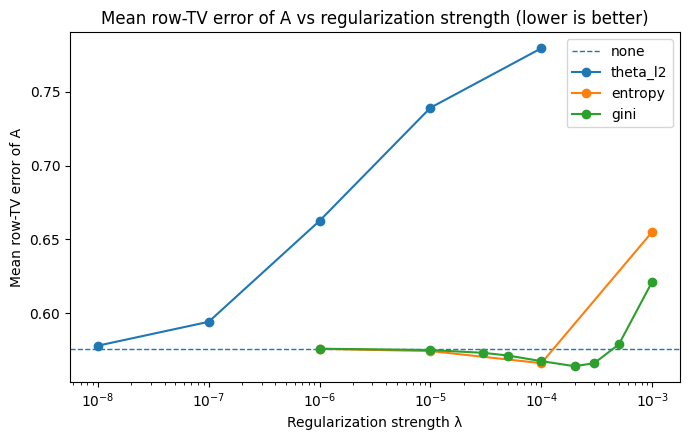

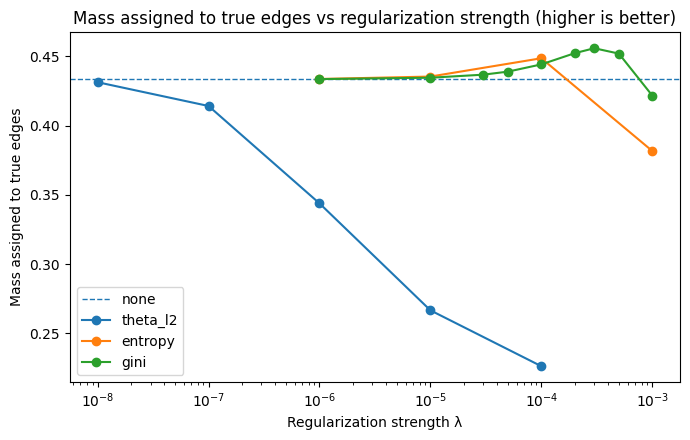

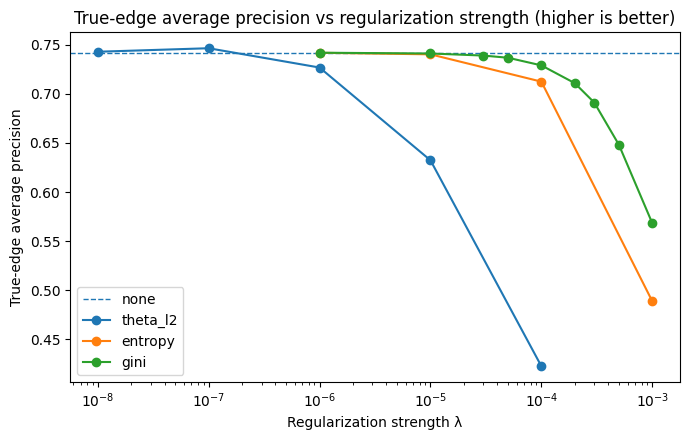

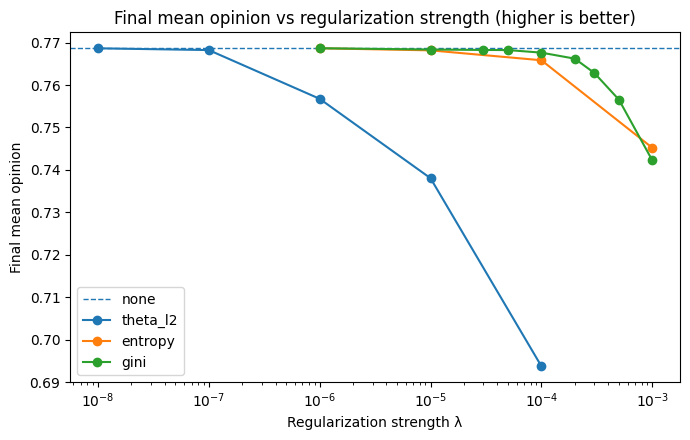

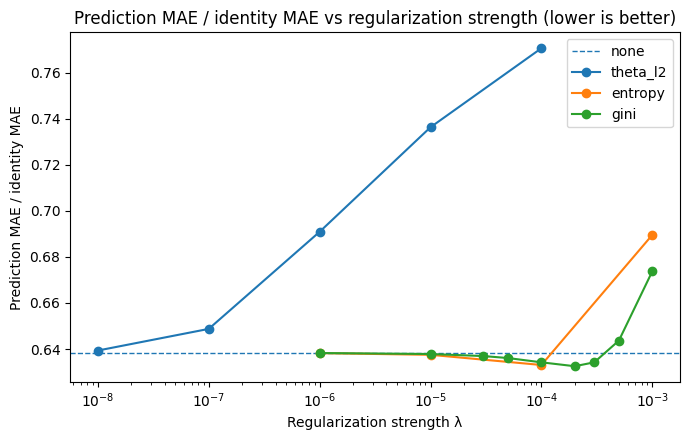

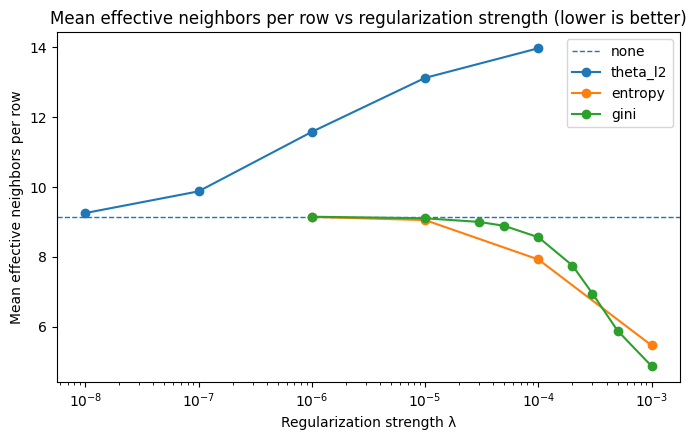

In [33]:
family_order = ["theta_l2", "entropy", "gini"]

for metric, ylabel, lower_better in [
    ("row_TV", "Mean row-TV error of A", True),
    ("true_edge_mass", "Mass assigned to true edges", False),
    ("edge_AP", "True-edge average precision", False),
    ("mean_end", "Final mean opinion", False),
    ("model_over_identity", "Prediction MAE / identity MAE", True),
    ("effective_neighbors", "Mean effective neighbors per row", True),
]:
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    base_y = float(ref[metric].mean())
    ax.axhline(base_y, linestyle="--", linewidth=1.0, label="none")

    for kind in family_order:
        g = (
            work[work["regularizer_kind"] == kind]
            .groupby("regularizer_lambda", as_index=False)[metric]
            .mean()
            .sort_values("regularizer_lambda")
        )
        ax.plot(g["regularizer_lambda"], g[metric], marker="o", label=kind)

    ax.set_xscale("log")
    ax.set_xlabel("Regularization strength λ")
    ax.set_ylabel(ylabel)
    ax.set_title(
        f"{ylabel} vs regularization strength"
        + (" (lower is better)" if lower_better else " (higher is better)")
    )
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Recovery–control trade-off

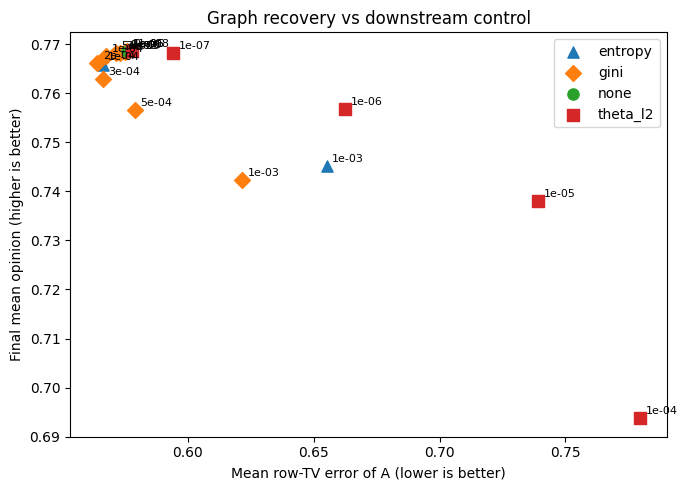

In [34]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))
markers = {"none": "o", "theta_l2": "s", "entropy": "^", "gini": "D"}

for kind, g in summary.groupby("regularizer_kind"):
    ax.scatter(
        g["row_TV"], g["mean_end"],
        marker=markers[kind], s=65, label=kind,
    )
    for _, r in g.iterrows():
        label = "0" if kind == "none" else f"{r['regularizer_lambda']:.0e}"
        ax.annotate(
            label,
            (r["row_TV"], r["mean_end"]),
            xytext=(4, 3), textcoords="offset points", fontsize=8,
        )

ax.set_xlabel("Mean row-TV error of A (lower is better)")
ax.set_ylabel("Final mean opinion (higher is better)")
ax.set_title("Graph recovery vs downstream control")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


## Focused Gini refinement

This table isolates the final Gini grid. `lambda_label` is kept in scientific
notation so the small values are not rounded to zero.

The purpose is to locate the recovery/control trade-off, not to optimize a
hidden scalar score.


In [35]:
gini_summary = (
    summary[summary["regularizer_kind"] == "gini"]
    .copy()
    .sort_values("regularizer_lambda")
)
gini_summary.insert(
    2,
    "lambda_label",
    gini_summary["regularizer_lambda"].map(lambda x: f"{x:.1e}")
)

display(
    gini_summary[
        [
            "lambda_label",
            "mean_end", "delta_control",
            "prediction_ratio",
            "row_TV", "delta_row_TV",
            "true_edge_mass", "edge_AP",
            "centrality_L1", "effective_neighbors",
        ]
    ].round(6)
)

print("\nGini — structured HK only:")
gini_hk = hk[hk["regularizer_kind"] == "gini"].copy().sort_values("regularizer_lambda")
gini_hk.insert(
    2,
    "lambda_label",
    gini_hk["regularizer_lambda"].map(lambda x: f"{x:.1e}")
)
display(
    gini_hk[
        [
            "lambda_label", "control", "delta_control",
            "prediction_ratio", "row_TV", "delta_row_TV",
            "true_edge_mass", "edge_AP", "centrality_L1",
            "effective_neighbors",
        ]
    ].round(6)
)

# Gini-only Pareto frontier for row-TV vs control.
gp = gini_summary.copy()
gini_pareto_idx = []
for i, r in gp.iterrows():
    dominated = False
    for j, q in gp.iterrows():
        if i == j:
            continue
        if (
            q["row_TV"] <= r["row_TV"]
            and q["mean_end"] >= r["mean_end"]
            and (
                q["row_TV"] < r["row_TV"]
                or q["mean_end"] > r["mean_end"]
            )
        ):
            dominated = True
            break
    if not dominated:
        gini_pareto_idx.append(i)

gini_pareto = gp.loc[gini_pareto_idx].sort_values("regularizer_lambda")
print("\nGini-only Pareto candidates:")
tmp = gini_pareto[
    [
        "regularizer_lambda", "row_TV", "true_edge_mass",
        "edge_AP", "mean_end", "prediction_ratio", "effective_neighbors",
    ]
].copy()
tmp.insert(1, "lambda_label", tmp["regularizer_lambda"].map(lambda x: f"{x:.1e}"))
display(tmp.drop(columns=["regularizer_lambda"]).round(6))


,lambda_label,mean_end,delta_control,prediction_ratio,row_TV,delta_row_TV,true_edge_mass,edge_AP,centrality_L1,effective_neighbors
4,1.0e-06,0.768670,0.000042,0.638264,0.575897,-0.000099,0.433634,0.741801,0.479972,9.149989
5,1.0e-05,0.768369,-0.000259,0.637848,0.575011,-0.000985,0.434631,0.741016,0.478988,9.105655
6,3.0e-05,0.768263,-0.000365,0.636948,0.573100,-0.002896,0.436841,0.738900,0.476815,9.001588
7,5.0e-05,0.768238,-0.000390,0.636091,0.571283,-0.004713,0.439030,0.736688,0.474679,8.888880
8,1.0e-04,0.767630,-0.000998,0.634230,0.567461,-0.008535,0.444259,0.728919,0.469769,8.562281
9,2.0e-04,0.766211,-0.002416,0.632539,0.564033,-0.011964,0.452352,0.710836,0.464242,7.752073
10,3.0e-04,0.762850,-0.005777,0.634239,0.566136,-0.009861,0.455923,0.691060,0.466063,6.950691
11,5.0e-04,0.756554,-0.012074,0.643677,0.578857,0.002861,0.452042,0.648119,0.482964,5.886083
12,1.0e-03,0.742246,-0.026381,0.673727,0.621469,0.045473,0.421752,0.568302,0.534506,4.868804



Gini — structured HK only:


,lambda_label,control,delta_control,prediction_ratio,row_TV,delta_row_TV,true_edge_mass,edge_AP,centrality_L1,effective_neighbors
4,1.0e-06,0.754236,0.000000,1.152640,0.736170,-0.000050,0.349221,0.470516,0.680301,12.384331
5,1.0e-05,0.751230,-0.003006,1.152638,0.735729,-0.000490,0.350266,0.470435,0.679428,12.302386
6,3.0e-05,0.748885,-0.005351,1.152638,0.734933,-0.001286,0.352752,0.470206,0.677309,12.101332
7,5.0e-05,0.749506,-0.004730,1.152644,0.734379,-0.001841,0.355489,0.469873,0.674902,11.870684
8,1.0e-04,0.745936,-0.008300,1.152714,0.734283,-0.001937,0.363494,0.466214,0.667574,11.144906
9,2.0e-04,0.750835,-0.003401,1.153210,0.738414,0.002194,0.382402,0.455398,0.651790,9.216440
10,3.0e-04,0.746143,-0.008093,1.154085,0.745746,0.009526,0.399708,0.447252,0.640453,7.345156
11,5.0e-04,0.728939,-0.025297,1.155759,0.762030,0.025811,0.419464,0.432665,0.642010,5.099124
12,1.0e-03,0.692218,-0.062019,1.156847,0.787671,0.051452,0.425705,0.413831,0.690083,3.690905



Gini-only Pareto candidates:


,lambda_label,row_TV,true_edge_mass,edge_AP,mean_end,prediction_ratio,effective_neighbors
4,1.0e-06,0.575897,0.433634,0.741801,0.768670,0.638264,9.149989
5,1.0e-05,0.575011,0.434631,0.741016,0.768369,0.637848,9.105655
6,3.0e-05,0.573100,0.436841,0.738900,0.768263,0.636948,9.001588
7,5.0e-05,0.571283,0.439030,0.736688,0.768238,0.636091,8.888880
8,1.0e-04,0.567461,0.444259,0.728919,0.767630,0.634230,8.562281
9,2.0e-04,0.564033,0.452352,0.710836,0.766211,0.632539,7.752073


## Edge-of-grid check

If the strongest observed setting for a family occurs at the smallest or
largest tested \(\lambda\), that family may need a small refinement before the
three-seed confirmation.


In [36]:
grid_rows = []

for kind in ["theta_l2", "entropy", "gini"]:
    g = summary[summary["regularizer_kind"] == kind].sort_values("regularizer_lambda")
    lambdas = g["regularizer_lambda"].to_numpy(float)

    for criterion, series, direction in [
        ("row_TV", g["row_TV"].to_numpy(float), "min"),
        ("control", g["mean_end"].to_numpy(float), "max"),
        ("true_edge_mass", g["true_edge_mass"].to_numpy(float), "max"),
    ]:
        idx = int(np.argmin(series) if direction == "min" else np.argmax(series))
        grid_rows.append({
            "regularizer_kind": kind,
            "criterion": criterion,
            "best_lambda": lambdas[idx],
            "best_value": series[idx],
            "at_lower_grid_edge": idx == 0,
            "at_upper_grid_edge": idx == len(lambdas) - 1,
        })

edge_check = pd.DataFrame(grid_rows)
display(edge_check.round(8))


,regularizer_kind,criterion,best_lambda,best_value,at_lower_grid_edge,at_upper_grid_edge
0,theta_l2,row_TV,1.000000e-08,0.577947,True,False
1,theta_l2,control,1.000000e-08,0.768651,True,False
2,theta_l2,true_edge_mass,1.000000e-08,0.431380,True,False
3,entropy,row_TV,1.000000e-04,0.566109,False,False
4,entropy,control,1.000000e-06,0.768662,True,False
5,entropy,true_edge_mass,1.000000e-04,0.448689,False,False
6,gini,row_TV,2.000000e-04,0.564033,False,False
7,gini,control,1.000000e-06,0.768670,True,False
8,gini,true_edge_mass,3.000000e-04,0.455923,False,False


## Compact hand-off table

In [37]:
compact = summary[
    [
        "regularizer_kind", "regularizer_lambda",
        "mean_end", "delta_control",
        "prediction_ratio",
        "row_TV", "delta_row_TV",
        "true_edge_mass", "edge_AP",
        "centrality_L1", "effective_neighbors",
    ]
].sort_values(["regularizer_kind", "regularizer_lambda"])

display(compact.round(6))

print("=" * 92)
print("REGULARIZATION SWEEP ANALYSIS COMPLETE")
print("=" * 92)
print("Conditions:", len(summary))
print("Paired environments per condition: 195")
print("Learning seed: 0 (coarse tuning)")
print()
print("Next decision after inspection:")
print("  - refine lambda if optimum is on a grid edge, OR")
print("  - validate the strongest candidate(s) with learning seeds 0,1,2.")


,regularizer_kind,regularizer_lambda,mean_end,delta_control,prediction_ratio,row_TV,delta_row_TV,true_edge_mass,edge_AP,centrality_L1,effective_neighbors
0,entropy,0.000001,0.768662,0.000034,0.638227,0.575823,-0.000173,0.433720,0.741728,0.479880,9.145097
1,entropy,0.000010,0.768169,-0.000458,0.637492,0.574308,-0.001688,0.435473,0.740164,0.478098,9.054728
2,entropy,0.000100,0.765836,-0.002792,0.633075,0.566109,-0.009887,0.448689,0.712357,0.465901,7.925858
3,entropy,0.001000,0.745212,-0.023416,0.689548,0.655201,0.079204,0.381751,0.488856,0.536793,5.462997
4,gini,0.000001,0.768670,0.000042,0.638264,0.575897,-0.000099,0.433634,0.741801,0.479972,9.149989
5,gini,0.000010,0.768369,-0.000259,0.637848,0.575011,-0.000985,0.434631,0.741016,0.478988,9.105655
6,gini,0.000030,0.768263,-0.000365,0.636948,0.573100,-0.002896,0.436841,0.738900,0.476815,9.001588
7,gini,0.000050,0.768238,-0.000390,0.636091,0.571283,-0.004713,0.439030,0.736688,0.474679,8.888880
8,gini,0.000100,0.767630,-0.000998,0.634230,0.567461,-0.008535,0.444259,0.728919,0.469769,8.562281
9,gini,0.000200,0.766211,-0.002416,0.632539,0.564033,-0.011964,0.452352,0.710836,0.464242,7.752073


REGULARIZATION SWEEP ANALYSIS COMPLETE
Conditions: 19
Paired environments per condition: 195
Learning seed: 0 (coarse tuning)

Next decision after inspection:
  - refine lambda if optimum is on a grid edge, OR
  - validate the strongest candidate(s) with learning seeds 0,1,2.
